# Imports

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve,
)

warnings.filterwarnings("ignore")


# Config

In [2]:
DATA_FILE = "../../data/processed/cardio_onc_prostate_04cleaned.csv"
OUT_DIR = "Results/LogisticRegression"
TARGET = "at_risk"
N_FOLDS = 5
SEED = 42
CS = np.logspace(-4, 4, 20)  # inverse-regularization grid

COL_L1 = "#E24B4A"
COL_L2 = "#378ADD"
COL_REF = "#999999"

os.makedirs(OUT_DIR, exist_ok = True)


# 1. Load data

- all recoding and type-casting done in preprocessing notebook

In [3]:
df = pd.read_csv(DATA_FILE)
print(f"Raw shape: {df.shape}")


Raw shape: (239, 53)


In [4]:
df["age_sq"] = df["age"] ** 2
df["bmi_sq"] = df["bmi"] ** 2
df["bmi_over30"] = (df["bmi"] > 30).astype(int)
df["age_htn"] = df["age"] * df["hx_htn"]
df["age_dm"] = df["age"] * df["hx_dm2"]
df["cad_dm"] = df["hx_cad"] * df["hx_dm2"]

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. Drop rows where TARGET is missing (n=36)
# ─────────────────────────────────────────────────────────────────────────────
df = df[df[TARGET].notna()].copy()
print(f"Shape after dropping missing target: {df.shape}")
print(f"Class distribution — 0: {(df[TARGET] == 0).sum()}  1: {(df[TARGET] == 1).sum()}")


Shape after dropping missing target: (203, 59)
Class distribution — 0: 124  1: 79


# 3. Define feature columns (verified against dtype printout)
Excluded:
- unique_patient_id              — row identifier
- ethnicity, specific_nht_used,  — raw strings (encoded versions kept)
- adt_agent, prescribing_provider
- nht_auth_date, nht_start_date, — raw datetimes (derived numerics kept)
- adt_start_date
- at_risk                        — target


In [6]:
continuous_features = [
    "bmi", "age", "sbp", "dbp", "ascvd_10yr",
    "days_auth_to_start", "days_adt_to_nht",
]

binary_features = [
    "hx_smoking", "family_hx_hd", "hx_htn",
    "bp_meds_prior", "bb_prior", "ace_arb_prior",
    "has_pcp", "hx_hld", "hx_high_tg",
    "statin_prior", "other_lipid_prior", "lipid_panel_checked",
    "hx_cad", "hx_mi_stent", "hx_chf", "hx_arrhythmia",
    "hx_carotid", "hx_pad", "hx_cva",
    "hx_dm2", "dm_noninsulin", "on_insulin",
    "a1c_checked", "glucose_over_200",
    "asa_use", "cards_prior", "cards_post", "cards_referral",
    "diet_counseling", "exercise_counseling",
    "echo_ordered", "ecg_done", "non_onc_provider",
]

encoded_features = [
    "ethnicity_enc", "specific_nht_used_enc",
    "adt_agent_enc", "prescribing_provider_enc",
]

all_features = continuous_features + binary_features + encoded_features

# Sanity check
missing_cols = [c for c in all_features if c not in df.columns]
if missing_cols:
    print(f"WARNING — columns not found in dataframe: {missing_cols}")
else:
    print(f"\nAll {len(all_features)} feature columns confirmed present in dataframe.")

print(f"  Continuous:    {len(continuous_features)}")
print(f"  Binary:        {len(binary_features)}")
print(f"  Encoded cats:  {len(encoded_features)}")


All 44 feature columns confirmed present in dataframe.
  Continuous:    7
  Binary:        33
  Encoded cats:  4


# 4. Build X, y — report per-column missingness

In [7]:
X_df = df[all_features].copy().astype(float)
y = df[TARGET].values.astype(int)

miss = X_df.isnull().sum()
miss = miss[miss > 0].sort_values(ascending = False)
print(f"\nFeature-matrix missingness (non-zero columns only):")
print(miss.to_string())
print(f"\nComplete cases if listwise deletion: {X_df.dropna().shape[0]} / {X_df.shape[0]}")
print("→ Using imputation instead of listwise deletion.\n")

X_arr = X_df.values



Feature-matrix missingness (non-zero columns only):
days_adt_to_nht       14
adt_agent_enc         11
ethnicity_enc          4
days_auth_to_start     1

Complete cases if listwise deletion: 185 / 203
→ Using imputation instead of listwise deletion.



# 5. Preprocessing pipeline
- Continuous  → median imputation → StandardScaler
- Binary/Enc  → mode imputation   (values already 0/1 or small int, no scaling)


In [8]:
cont_idx = list(range(len(continuous_features)))
disc_idx = list(range(len(continuous_features), len(all_features)))

preprocessor = ColumnTransformer(
    transformers = [
        ("cont", Pipeline([
            ("impute", SimpleImputer(strategy = "median")),
            ("scale", StandardScaler()),
        ]), cont_idx),
        ("disc", Pipeline([
            ("impute", SimpleImputer(strategy = "most_frequent")),
        ]), disc_idx),
    ],
    remainder = "drop",
)


# 6. Model definitions
- LogisticRegressionCV tunes C over CS grid using the same 5-fold CV splitter


In [9]:
cv_splitter = StratifiedKFold(n_splits = N_FOLDS, shuffle = True, random_state = SEED)

models = {
    "L1 (Lasso)": LogisticRegressionCV(
        Cs = CS,
        penalty = "l1",
        class_weight="balanced",
        solver = "liblinear",  # only solver supporting L1
        cv = cv_splitter,
        scoring = "roc_auc",
        max_iter = 5000,
        random_state = SEED,
        n_jobs = -1,
    ),
    "L2 (Ridge)": LogisticRegressionCV(
        Cs = CS,
        penalty = "l2",
        class_weight="balanced",
        solver = "lbfgs",
        cv = cv_splitter,
        scoring = "roc_auc",
        max_iter = 5000,
        random_state = SEED,
        n_jobs = -1,
    ),
}


In [10]:
from sklearn.metrics import precision_recall_curve
import numpy as np

summary_rows = []
fitted_pipes = {}

scoring_metrics = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "accuracy": "accuracy",
    "f1": "f1",
    "recall": "recall",
    "precision": "precision",
}

for name, clf in models.items():
    print(f"\n{'=' * 60}")
    print(f"  {name}")
    print(f"{'=' * 60}")

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("clf", clf),
    ])

    # CV metrics (NO leakage change)
    cv_results = cross_validate(
        pipe, X_arr, y,
        cv=cv_splitter,
        scoring=scoring_metrics,
        return_train_score=True,
        n_jobs=-1,
    )

    for metric in scoring_metrics:
        vals = cv_results[f"test_{metric}"]
        print(f"  {metric:<22} {vals.mean():.4f} ± {vals.std():.4f}")

    # Fit final model
    pipe.fit(X_arr, y)
    fitted_pipes[name] = pipe

    print(f"\n  Best C (tuned by inner CV): {clf.C_[0]:.6f}")

    # Threshold tuning (CORRECT way)
    probs = pipe.predict_proba(X_arr)[:, 1]
    prec, rec, thresh = precision_recall_curve(y, probs)

    # avoid divide-by-zero issues
    f1_scores = (2 * prec * rec) / (prec + rec + 1e-10)

    best_thresh = thresh[np.argmax(f1_scores[:-1])]  # align shapes

    print(f"  Best threshold (train-set approx): {best_thresh:.3f}")

    row = {"Model": name}
    for metric in scoring_metrics:
        vals = cv_results[f"test_{metric}"]
        row[f"{metric}_mean"] = vals.mean()
        row[f"{metric}_std"] = vals.std()

    row["best_threshold"] = best_thresh
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(OUT_DIR, "cv_summary.csv"), index=False)

print(f"\nSaved → {os.path.join(OUT_DIR, 'cv_summary.csv')}")


  L1 (Lasso)
  roc_auc                0.6086 ± 0.0462
  average_precision      0.5461 ± 0.0603
  accuracy               0.5955 ± 0.0504
  f1                     0.5065 ± 0.0438
  recall                 0.5308 ± 0.0402
  precision              0.4879 ± 0.0634

  Best C (tuned by inner CV): 4.281332
  Best threshold (train-set approx): 0.428

  L2 (Ridge)
  roc_auc                0.6281 ± 0.0752
  average_precision      0.5561 ± 0.0670
  accuracy               0.6206 ± 0.0405
  f1                     0.5246 ± 0.0621
  recall                 0.5442 ± 0.0918
  precision              0.5119 ± 0.0453

  Best C (tuned by inner CV): 1438.449888
  Best threshold (train-set approx): 0.496

Saved → Results/LogisticRegression/cv_summary.csv


# 8. Coefficient table
- After ColumnTransformer: continuous features first, then binary + encoded


In [11]:
feature_names_out = continuous_features + binary_features + encoded_features

coef_df = pd.DataFrame({
    "feature": feature_names_out,
    "L1_coef": fitted_pipes["L1 (Lasso)"]["clf"].coef_[0],
    "L2_coef": fitted_pipes["L2 (Ridge)"]["clf"].coef_[0],
})
coef_df["L1_abs"] = coef_df["L1_coef"].abs()
coef_df = coef_df.sort_values("L1_abs", ascending = False).reset_index(drop = True)

coef_df.to_csv(os.path.join(OUT_DIR, "coefficients.csv"), index = False)
print(f"Saved → {os.path.join(OUT_DIR, 'coefficients.csv')}")

zeroed = coef_df[coef_df["L1_coef"] == 0]["feature"].tolist()
print(f"\nL1-zeroed features ({len(zeroed)}): {zeroed}")


Saved → Results/LogisticRegression/coefficients.csv

L1-zeroed features (3): ['exercise_counseling', 'other_lipid_prior', 'specific_nht_used_enc']


# 9. Plot: Coefficient comparison
- top 20 by |L1 coef|


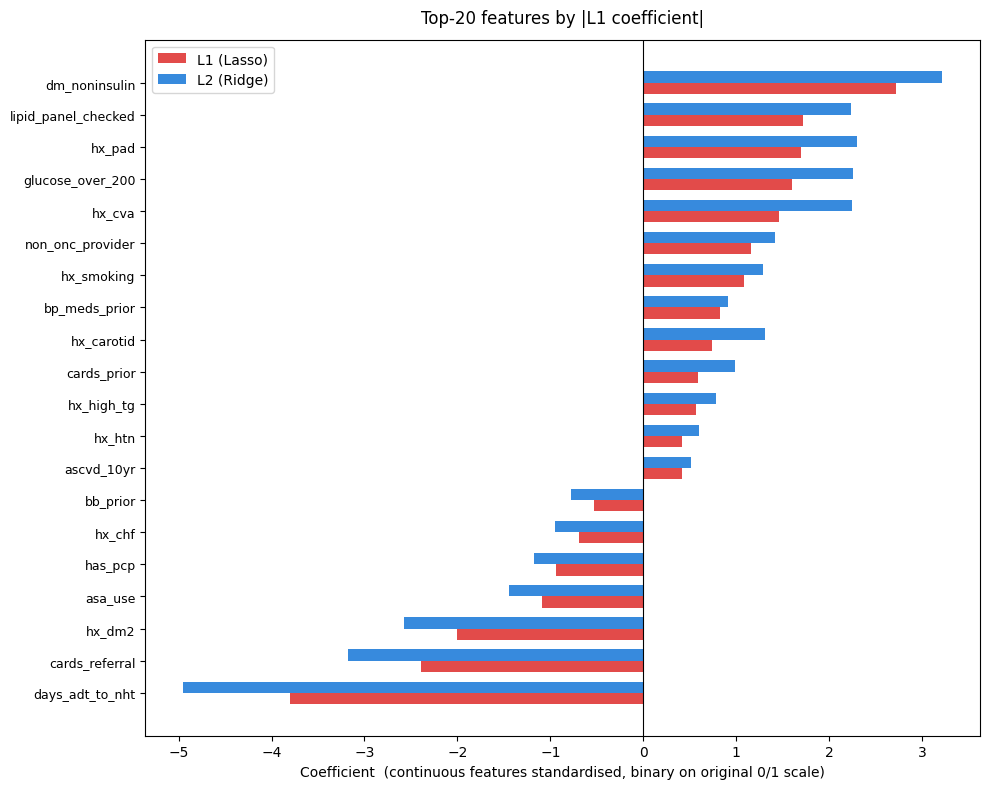

Saved → Results/LogisticRegression/coef_comparison.png


In [12]:
top20 = coef_df.head(20).sort_values("L1_coef")
x = np.arange(len(top20))
w = 0.35

fig, ax = plt.subplots(figsize = (10, 8))
ax.barh(x - w / 2, top20["L1_coef"], w, color = COL_L1, label = "L1 (Lasso)")
ax.barh(x + w / 2, top20["L2_coef"], w, color = COL_L2, label = "L2 (Ridge)")
ax.axvline(0, color = "black", lw = 0.8)
ax.set_yticks(x)
ax.set_yticklabels(top20["feature"], fontsize = 9)
ax.set_xlabel("Coefficient  (continuous features standardised, binary on original 0/1 scale)",
              fontsize = 10)
ax.set_title("Top-20 features by |L1 coefficient|", fontsize = 12, pad = 12)
ax.legend(fontsize = 10)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "coef_comparison.png"), dpi = 150, bbox_inches = "tight")
plt.show()
print(f"Saved → {os.path.join(OUT_DIR, 'coef_comparison.png')}")


# 10. Plot: CV metric bar chart (mean ± std)


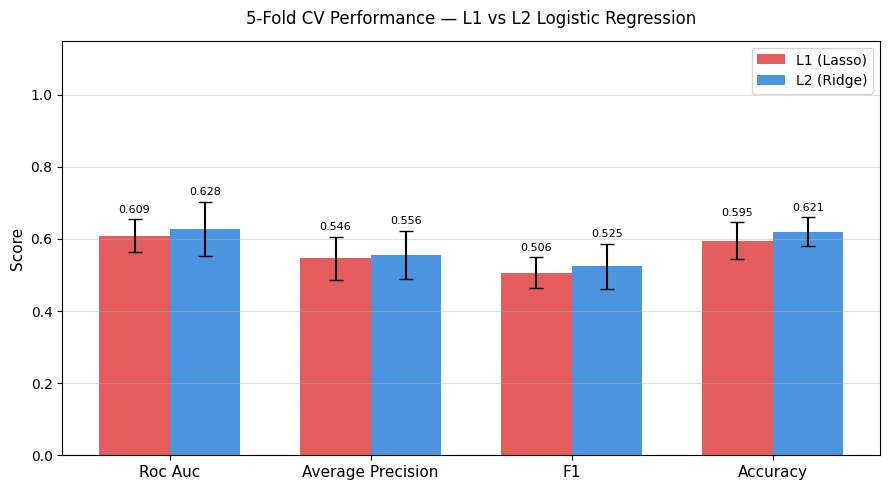

Saved → Results/LogisticRegression/cv_metrics_comparison.png


In [13]:
metrics_plot = ["roc_auc", "average_precision", "f1", "accuracy"]
x = np.arange(len(metrics_plot))
w = 0.35

fig, ax = plt.subplots(figsize = (9, 5))
for i, (name, color) in enumerate(zip(["L1 (Lasso)", "L2 (Ridge)"], [COL_L1, COL_L2])):
    row = summary_df[summary_df["Model"] == name].iloc[0]
    means = [row[f"{m}_mean"] for m in metrics_plot]
    stds = [row[f"{m}_std"] for m in metrics_plot]
    offset = (i - 0.5) * w
    ax.bar(x + offset, means, w, yerr = stds, color = color, label = name,
           capsize = 5, error_kw = {"lw": 1.5}, alpha = 0.9)
    for xi, (m, s) in zip(x + offset, zip(means, stds)):
        ax.text(xi, m + s + 0.012, f"{m:.3f}", ha = "center", va = "bottom", fontsize = 8)

ax.set_xticks(x)
ax.set_xticklabels([m.replace("_", " ").title() for m in metrics_plot], fontsize = 11)
ax.set_ylabel("Score", fontsize = 11)
ax.set_ylim(0, 1.15)
ax.set_title("5-Fold CV Performance — L1 vs L2 Logistic Regression", fontsize = 12, pad = 12)
ax.legend(fontsize = 10)
ax.yaxis.grid(True, alpha = 0.4)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "cv_metrics_comparison.png"), dpi = 150, bbox_inches = "tight")
plt.show()
print(f"Saved → {os.path.join(OUT_DIR, 'cv_metrics_comparison.png')}")


# 11. Plot: ROC & PR curves
- fold-level mean ± std band


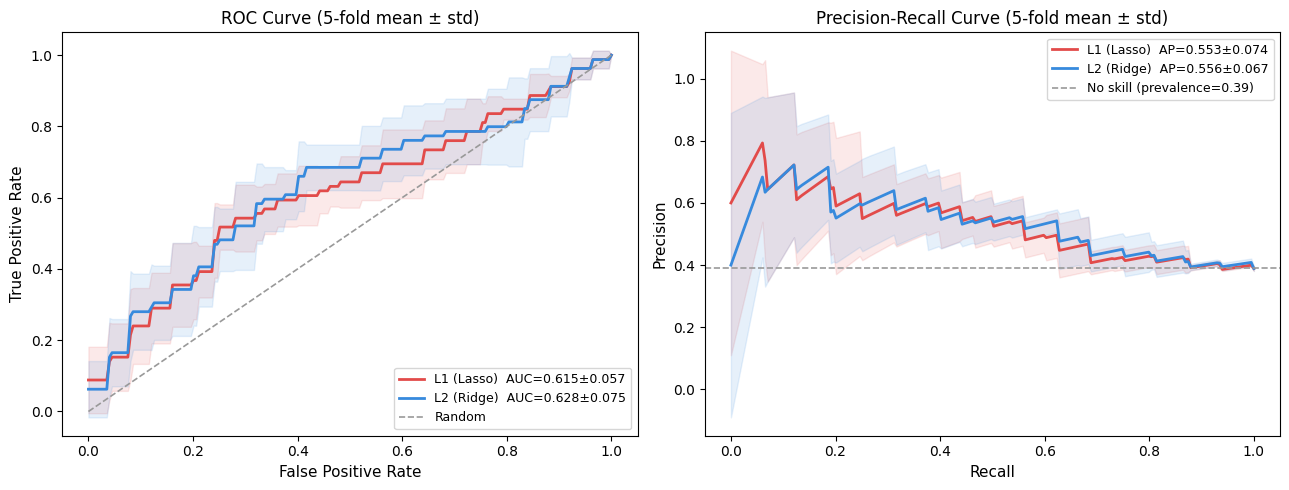

Saved → Results/LogisticRegression/roc_pr_curves.png


In [14]:
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize = (13, 5))

for name, color in zip(["L1 (Lasso)", "L2 (Ridge)"], [COL_L1, COL_L2]):
    clf = models[name]
    pipe = Pipeline([("preprocess", preprocessor), ("clf", clf)])

    tprs, precs, aucs, aps = [], [], [], []
    base_fpr = np.linspace(0, 1, 200)
    base_rec = np.linspace(0, 1, 200)[::-1]

    for train_idx, test_idx in cv_splitter.split(X_arr, y):
        pipe.fit(X_arr[train_idx], y[train_idx])
        proba = pipe.predict_proba(X_arr[test_idx])[:, 1]

        fpr, tpr, _ = roc_curve(y[test_idx], proba)
        tprs.append(np.interp(base_fpr, fpr, tpr))
        aucs.append(roc_auc_score(y[test_idx], proba))

        prec, rec, _ = precision_recall_curve(y[test_idx], proba)
        precs.append(np.interp(base_rec, rec[::-1], prec[::-1]))
        aps.append(average_precision_score(y[test_idx], proba))

    mean_tpr = np.mean(tprs, axis = 0)
    std_tpr = np.std(tprs, axis = 0)
    mean_prec = np.mean(precs, axis = 0)
    std_prec = np.std(precs, axis = 0)
    mean_auc = np.mean(aucs);
    std_auc = np.std(aucs)
    mean_ap = np.mean(aps);
    std_ap = np.std(aps)

    ax_roc.plot(base_fpr, mean_tpr, color = color, lw = 2,
                label = f"{name}  AUC={mean_auc:.3f}±{std_auc:.3f}")
    ax_roc.fill_between(base_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                        color = color, alpha = 0.12)

    ax_pr.plot(base_rec, mean_prec, color = color, lw = 2,
               label = f"{name}  AP={mean_ap:.3f}±{std_ap:.3f}")
    ax_pr.fill_between(base_rec, mean_prec - std_prec, mean_prec + std_prec,
                       color = color, alpha = 0.12)

ax_roc.plot([0, 1], [0, 1], ls = "--", color = COL_REF, lw = 1.2, label = "Random")
ax_roc.set_xlabel("False Positive Rate", fontsize = 11)
ax_roc.set_ylabel("True Positive Rate", fontsize = 11)
ax_roc.set_title("ROC Curve (5-fold mean ± std)", fontsize = 12)
ax_roc.legend(fontsize = 9, loc = "lower right")

base_rate = y.mean()
ax_pr.axhline(base_rate, ls = "--", color = COL_REF, lw = 1.2,
              label = f"No skill (prevalence={base_rate:.2f})")
ax_pr.set_xlabel("Recall", fontsize = 11)
ax_pr.set_ylabel("Precision", fontsize = 11)
ax_pr.set_title("Precision-Recall Curve (5-fold mean ± std)", fontsize = 12)
ax_pr.legend(fontsize = 9, loc = "upper right")

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "roc_pr_curves.png"), dpi = 150, bbox_inches = "tight")
plt.show()
print(f"Saved → {os.path.join(OUT_DIR, 'roc_pr_curves.png')}")



L1 (Lasso) — Classification Report (full-data fit):
              precision    recall  f1-score   support

           0       0.88      0.77      0.82       124
           1       0.69      0.84      0.76        79

    accuracy                           0.79       203
   macro avg       0.79      0.80      0.79       203
weighted avg       0.81      0.79      0.80       203


L2 (Ridge) — Classification Report (full-data fit):
              precision    recall  f1-score   support

           0       0.89      0.78      0.83       124
           1       0.71      0.85      0.77        79

    accuracy                           0.81       203
   macro avg       0.80      0.82      0.80       203
weighted avg       0.82      0.81      0.81       203



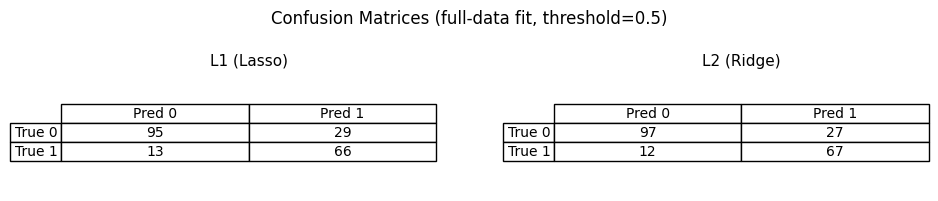

In [15]:
from sklearn.metrics import confusion_matrix, classification_report

fig, axes = plt.subplots(1, 2, figsize=(10, 2))

for ax, (name, _) in zip(axes, zip(["L1 (Lasso)", "L2 (Ridge)"], [COL_L1, COL_L2])):
    clf = models[name]
    pipe = Pipeline([("preprocess", preprocessor), ("clf", clf)])
    pipe.fit(X_arr, y)
    y_pred = pipe.predict(X_arr)

    # Confusion matrix
    cm = confusion_matrix(y, y_pred)

    table = ax.table(
        cellText=cm,
        rowLabels=["True 0", "True 1"],
        colLabels=["Pred 0", "Pred 1"],
        loc="center",
        cellLoc="center"
    )

    table.scale(1.5, 1.5)
    ax.set_title(name, fontsize=11)
    ax.axis("off")

    # KEEP printed classification report
    print(f"\n{name} — Classification Report (full-data fit):")
    print(classification_report(y, y_pred))

plt.suptitle("Confusion Matrices (full-data fit, threshold=0.5)", fontsize=12)
plt.tight_layout()
plt.show()

# 13. Final summary printout


In [16]:
print(f"\n{'=' * 60}")
print("  FINAL SUMMARY — 5-Fold CV Metrics")
print(f"{'=' * 60}")
for _, row in summary_df.iterrows():
    clf_name = row["Model"]
    best_c = fitted_pipes[clf_name]["clf"].C_[0]
    print(f"\n  {clf_name}   (best C = {best_c:.6f})")
    for m in scoring_metrics:
        print(f"    {m:<22} {row[f'{m}_mean']:.4f} ± {row[f'{m}_std']:.4f}")

print(f"\nAll outputs saved to: {OUT_DIR}/")


  FINAL SUMMARY — 5-Fold CV Metrics

  L1 (Lasso)   (best C = 4.281332)
    roc_auc                0.6086 ± 0.0462
    average_precision      0.5461 ± 0.0603
    accuracy               0.5955 ± 0.0504
    f1                     0.5065 ± 0.0438
    recall                 0.5308 ± 0.0402
    precision              0.4879 ± 0.0634

  L2 (Ridge)   (best C = 1438.449888)
    roc_auc                0.6281 ± 0.0752
    average_precision      0.5561 ± 0.0670
    accuracy               0.6206 ± 0.0405
    f1                     0.5246 ± 0.0621
    recall                 0.5442 ± 0.0918
    precision              0.5119 ± 0.0453

All outputs saved to: Results/LogisticRegression/
